In [34]:
import numpy as np
import h5py
import re
import csv
import math
import pandas as pd
import matplotlib.pyplot as plt
from pandas import read_excel
from sklearn.model_selection import train_test_split
from gensim.models import Word2Vec
from sklearn import metrics
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
import seaborn as sns
#Algorithm
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import BernoulliNB
# For Output
from sklearn.metrics import precision_recall_fscore_support
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize

## Importing the Data SET

In [35]:
df_data =pd.read_csv('sevenk.csv')

df_data

,comments,reaction_type
0,আগের জীবনে অনেক পূণ্য করেছিলাম বলে এই জীবনে আদ...,negative
1,এটার সেকেন্ড পার্ট চাই দিদি। আজ শুধু রাবণের রো...,negative
2,রাবণের ব্যাটা কিন্তু যথেষ্ঠ করে,negative
3,বিভীষণ আবার আমার লাল কালো শাড়িটা ঝেঁপে দিয়েছ...,negative
4,সত্যি দিদি হাসতে হাসতে পেট ব্যথা হয়ে গেলো আর ক...,positive
...,...,...
21170,আপনি যদি মুসলিম হউন প্লিজ সালাম দিয়ে ভিডিওটা শ...,negative
21171,অসাধারন লেগেছে ভালো লেগেছে,negative
21172,স্যতি অসাধারণ,negative
21173,2014 তে এই ফিল্ম টি দেখছিলাম। অসাধারণ একটি মুভি।,negative


## Preprocessing

In [36]:
def text_to_word_list(text):
    text = text.split()
    return text

def replace_strings(text):
    emoji_pattern = re.compile("["
                           u"\U0001F600-\U0001F64F"  # emoticons
                           u"\U0001F300-\U0001F5FF"  # symbols & pictographs
                           u"\U0001F680-\U0001F6FF"  # transport & map symbols
                           u"\U0001F1E0-\U0001F1FF"  # flags (iOS)
                           u"\U00002702-\U000027B0"
                           u"\U000024C2-\U0001F251"
                           u"\u00C0-\u017F"          #latin
                           u"\u2000-\u206F"          #generalPunctuations

                           "]+", flags=re.UNICODE)
    english_pattern=re.compile('[a-zA-Z0-9]+', flags=re.I)
    #latin_pattern=re.compile('[A-Za-z\u00C0-\u00D6\u00D8-\u00f6\u00f8-\u00ff\s]*',)

    text=emoji_pattern.sub(r'', text)
    text=english_pattern.sub(r'', text)

    return text

def remove_punctuations(my_str):
    # define punctuation
    punctuations = '''````£|¢|Ñ+-*/=EROero৳০১২৩৪৫৬৭৮৯012–34567•89।!()-[]{};:'"“\’,<>./?@#$%^&*_~‘—॥”‰🤣⚽️✌�￰৷￰'''

    no_punct = ""
    for char in my_str:
        if char not in punctuations:
            no_punct = no_punct + char

    # display the unpunctuated string
    return no_punct

def joining(text):
    out=' '.join(text)
    return out

def preprocessing(text):
    out=remove_punctuations(replace_strings(text))
    return out

In [37]:
df_data['comments'] = df_data.comments.apply(lambda x: preprocessing(str(x)))

In [38]:
df_data

,comments,reaction_type
0,আগের জীবনে অনেক পূণ্য করেছিলাম বলে এই জীবনে আদ...,negative
1,এটার সেকেন্ড পার্ট চাই দিদি আজ শুধু রাবণের রোস...,negative
2,রাবণের ব্যাটা কিন্তু যথেষ্ঠ করে,negative
3,বিভীষণ আবার আমার লাল কালো শাড়িটা ঝেঁপে দিয়েছ...,negative
4,সত্যি দিদি হাসতে হাসতে পেট ব্যথা হয়ে গেলো আর ক...,positive
...,...,...
21170,আপনি যদি মুসলিম হউন প্লিজ সালাম দিয়ে ভিডিওটা শ...,negative
21171,অসাধারন লেগেছে ভালো লেগেছে,negative
21172,স্যতি অসাধারণ,negative
21173,তে এই ফিল্ম টি দেখছিলাম অসাধারণ একটি মুভি,negative


## Stopwords Removal

In [39]:
data1 = pd.read_excel('stopwords_bangla.xlsx')
display(data1)
stop = data1['words'].tolist()

,Unnamed: 0,words
0,0,অই
1,1,অগত্যা
2,2,অত: পর
3,3,অতএব
4,4,অথচ
...,...,...
727,727,হয়েই
728,728,হয়েছিল
729,729,হয়েছে
730,730,হয়েছেন


In [40]:
def stopwordRemoval(text):    
    x=str(text)
    l=x.split()

    stm=[elem for elem in l if elem not in stop]
    
    out=' '.join(stm)
    
    return str(out)

In [41]:
df_data['comments'] = df_data.comments.apply(lambda x: stopwordRemoval(str(x)))

## Stemming

In [42]:
#make sure to turn on internet on your kernel
from bangla_stemmer.stemmer import stemmer
## stemmer function
def stem_text (x):
  stmr = stemmer.BanglaStemmer()
  words=x.split(' ')
  stm = stmr.stem(words)
  words=(' ').join(stm)
  return words

In [43]:
df_data['comments']=df_data['comments'].apply(stem_text)

applied fourth rules..
applied second rules..
applied fourth rules..
applied first rules..
applied fourth rules..
applied second rules..
applied fourth rules..
applied first rules..
applied fourth rules..
applied first rules..
applied fourth rules..
applied second rules..
applied fourth rules..
applied fourth rules..
applied fourth rules..
applied first rules..
applied first rules..
applied fourth rules..
applied second rules..
applied first rules..
applied fourth rules..
applied fourth rules..
applied fourth rules..
applied second rules..
applied fourth rules..
applied first rules..
applied first rules..
applied third rules..
applied second rules..
applied fourth rules..
applied fourth rules..
applied fourth rules..
applied first rules..
applied first rules..
applied first rules..
applied fourth rules..
applied second rules..
applied first rules..
applied fourth rules..
applied third rules..
applied first rules..
applied fourth rules..
applied fourth rules..
applied first rules..
appl

## Checking the Data

In [44]:
df_data

,comments,reaction_type
0,আগ জীবনে পূণ্য করেছি জীবনে আদিপুরুষ হয়নিযতব প্...,negative
1,এটা পার্ট চাই দিদি রাবণ রোস্ট মন ভর না,negative
2,রাবণ ব্যা যথেষ্ঠ,negative
3,বিভীষণ কালো শাড়ি ঝেঁপে ছিলো দি,negative
4,সত্যি দিদি হাস হাস পেট ব্যথা গেলো কবিতা গুলো ছিলো,positive
...,...,...
21170,মুসলিম হউন প্লিজ সাল ভিডিও ভিডি মিস করিনা চ্যা...,negative
21171,অসাধারন লাগ ভালো লাগ,negative
21172,স্যতি অসাধারণ,negative
21173,তে ফিল্ম দেখছি অসাধারণ মুভি,negative


## Removing Null values

In [45]:
#display non-null values
df_data = df_data.dropna()

## Removing Small Texts

In [46]:
#counting text length
# df_data['count'] = df_train['comments'].str.split().str.len()
# Remove the text with words less than 5
# df_data= df_data.loc[df_data['count']>5]

## Checking the Data

In [47]:
df_data

,comments,reaction_type
0,আগ জীবনে পূণ্য করেছি জীবনে আদিপুরুষ হয়নিযতব প্...,negative
1,এটা পার্ট চাই দিদি রাবণ রোস্ট মন ভর না,negative
2,রাবণ ব্যা যথেষ্ঠ,negative
3,বিভীষণ কালো শাড়ি ঝেঁপে ছিলো দি,negative
4,সত্যি দিদি হাস হাস পেট ব্যথা গেলো কবিতা গুলো ছিলো,positive
...,...,...
21170,মুসলিম হউন প্লিজ সাল ভিডিও ভিডি মিস করিনা চ্যা...,negative
21171,অসাধারন লাগ ভালো লাগ,negative
21172,স্যতি অসাধারণ,negative
21173,তে ফিল্ম দেখছি অসাধারণ মুভি,negative


## Changing Labels to Numbers


In [48]:
df_data["reaction_type"].replace({"negative": "0", "positive": "1","neutral": "2" }, inplace=True)

C:\Users\debbi\AppData\Local\Temp\ipykernel_18008\1620500157.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_data["reaction_type"].replace({"negative": "0", "positive": "1","neutral": "2" }, inplace=True)


In [49]:
df_data

,comments,reaction_type
0,আগ জীবনে পূণ্য করেছি জীবনে আদিপুরুষ হয়নিযতব প্...,0
1,এটা পার্ট চাই দিদি রাবণ রোস্ট মন ভর না,0
2,রাবণ ব্যা যথেষ্ঠ,0
3,বিভীষণ কালো শাড়ি ঝেঁপে ছিলো দি,0
4,সত্যি দিদি হাস হাস পেট ব্যথা গেলো কবিতা গুলো ছিলো,1
...,...,...
21170,মুসলিম হউন প্লিজ সাল ভিডিও ভিডি মিস করিনা চ্যা...,0
21171,অসাধারন লাগ ভালো লাগ,0
21172,স্যতি অসাধারণ,0
21173,তে ফিল্ম দেখছি অসাধারণ মুভি,0


## Splitin Data into 80% Train and 20% Test

In [50]:
# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(df_data['comments'], df_data['reaction_type'], test_size=0.2, random_state=42)

## Feature Extraction with TFIDF

In [51]:

# TF-IDF Vectorization
tfidf_vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1, 3))
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)


In [52]:
# Train Bernoulli Naive Bayes model
bnb = BernoulliNB()
bnb.fit(X_train_tfidf, y_train)

# Make predictions
y_pred = bnb.predict(X_test_tfidf)
y_prob = bnb.predict_proba(X_test_tfidf)

# Calculate metrics
accuracy = bnb.score(X_test_tfidf, y_test)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
fscore = f1_score(y_test, y_pred, average='weighted')

print(f"Testing Accuracy: {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall : {recall:.4f}")
print(f"F1 Score : {fscore:.4f}")


Testing Accuracy: 0.4829
Precision : 0.5100
Recall : 0.4829
F1 Score : 0.4759


## Generate and Plot the Confusion Matrix

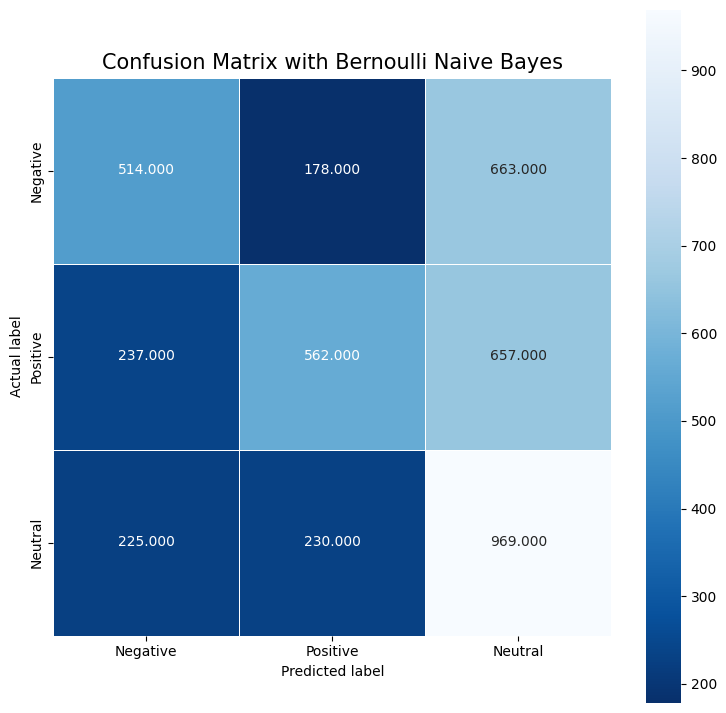

In [53]:
# Generate confusion matrix
labels = ['0', '1', '2']
cm = confusion_matrix(y_test, y_pred, labels=labels)
cm_df = pd.DataFrame(cm, index=['Negative', 'Positive', 'Neutral'], columns=['Negative', 'Positive', 'Neutral'])

# Plot confusion matrix
plt.figure(figsize=(9, 9))
sns.heatmap(cm_df, annot=True, fmt=".3f", linewidths=.5, square=True, cmap='Blues_r')
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
plt.title('Confusion Matrix with Bernoulli Naive Bayes', size=15)
plt.show()


## Generate and Display the Classification Report

In [54]:
# Generate classification report
report = pd.DataFrame(classification_report(y_test, y_pred, labels=labels, output_dict=True)).transpose()
report = report.rename(index={'0': 'Negative', '1': 'Positive', '2': 'Neutral'})
report[['precision', 'recall', 'f1-score']] = report[['precision', 'recall', 'f1-score']].apply(lambda x: round(x * 100, 2))

# Display classification report
print("Classification Report:")
print(report)

Classification Report:
              precision  recall  f1-score      support
Negative          52.66   37.93     44.10  1355.000000
Positive          57.94   38.60     46.33  1456.000000
Neutral           42.33   68.05     52.19  1424.000000
accuracy          48.29   48.29     48.29     0.482881
macro avg         50.98   48.19     47.54  4235.000000
weighted avg      51.00   48.29     47.59  4235.000000


## Plot ROC Curves and Class Distribution Bar Plot

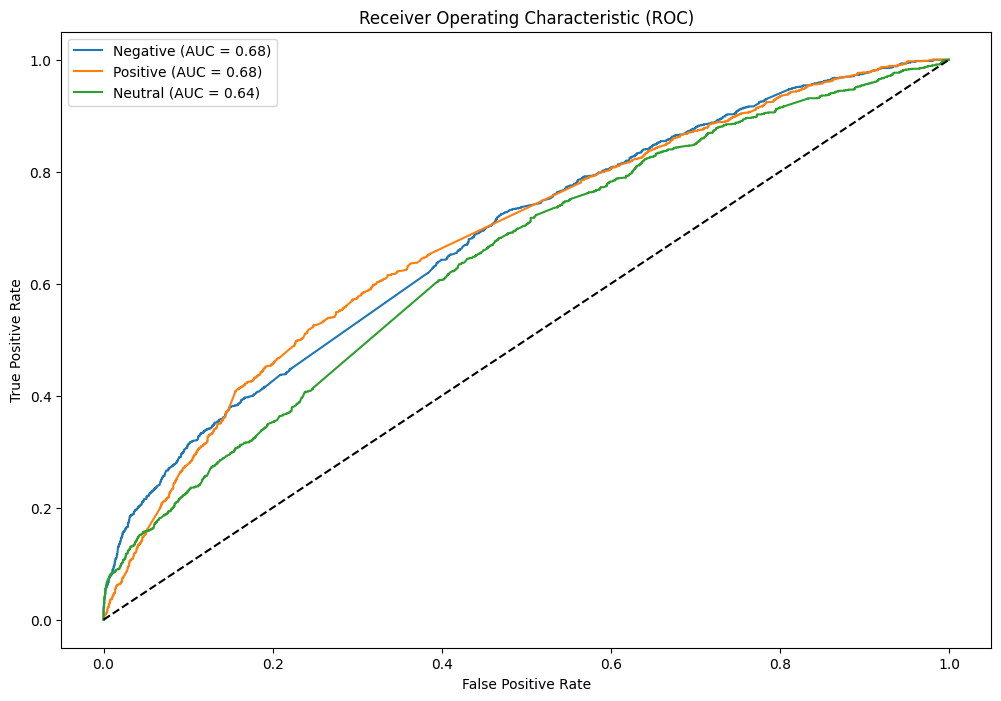

In [57]:
# ROC Curve
y_test_bin = label_binarize(y_test, classes=labels)
n_classes = y_test_bin.shape[1]

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves
plt.figure(figsize=(12, 8))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f'{["Negative", "Positive", "Neutral"][i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc='best')
plt.show()



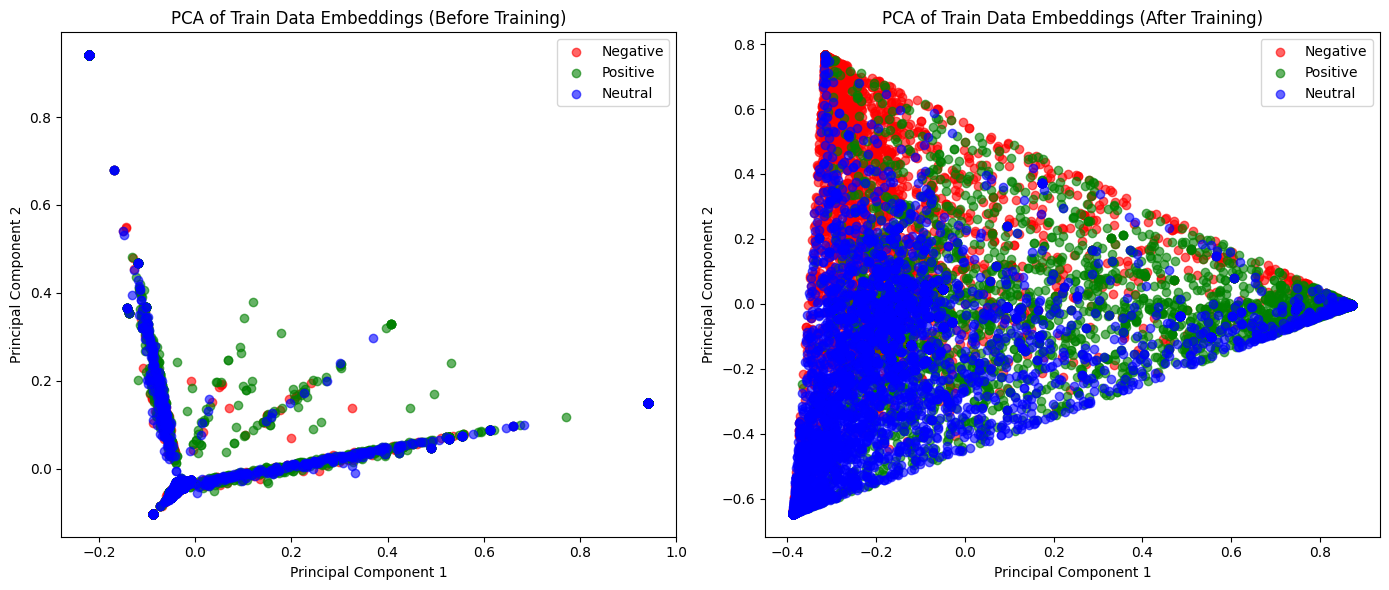

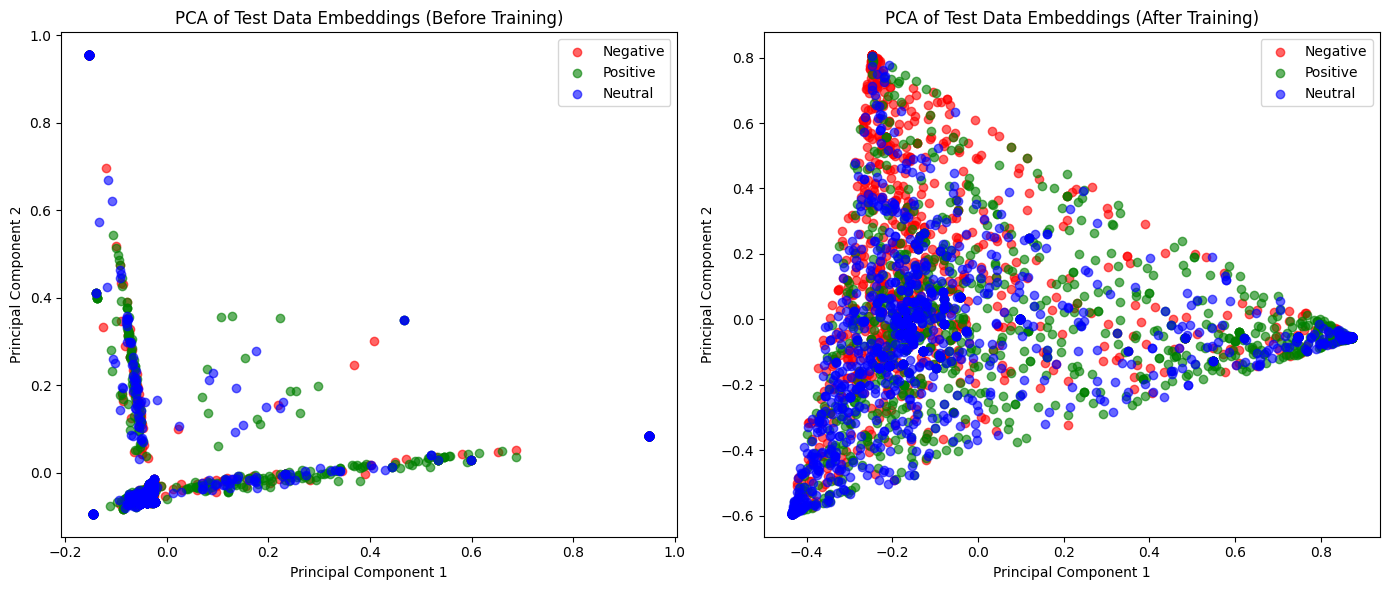

In [63]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Function to get PCA embeddings
def get_pca_embeddings(embeddings):
    pca = PCA(n_components=2)
    if hasattr(embeddings, 'toarray'):
        embeddings = embeddings.toarray()
    return pca.fit_transform(embeddings)

# Function to plot PCA side by side
def plot_pca_side_by_side(before_embeddings, after_embeddings, labels, title):
    before_pca = get_pca_embeddings(before_embeddings)
    after_pca = get_pca_embeddings(after_embeddings)
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    label_names = ['Negative', 'Positive', 'Neutral']
    colors = ['red', 'green', 'blue']
    
    for i, label in enumerate(label_names):
        indices = np.where(labels == str(i))
        axes[0].scatter(before_pca[indices, 0], before_pca[indices, 1], label=label, alpha=0.6, color=colors[i])
    axes[0].set_title(f'PCA of {title} Embeddings (Before Training)')
    
    for i, label in enumerate(label_names):
        indices = np.where(labels == str(i))
        axes[1].scatter(after_pca[indices, 0], after_pca[indices, 1], label=label, alpha=0.6, color=colors[i])
    axes[1].set_title(f'PCA of {title} Embeddings (After Training)')
    for ax in axes:
        ax.set_xlabel('Principal Component 1')
        ax.set_ylabel('Principal Component 2')
        ax.legend()
    plt.tight_layout()
    plt.show()

# Transform the data using the model's predictions
X_train_tfidf_transformed = bnb.predict_proba(X_train_tfidf)
X_test_tfidf_transformed = bnb.predict_proba(X_test_tfidf)

# Generate PCA visualizations for train data
plot_pca_side_by_side(X_train_tfidf, X_train_tfidf_transformed, y_train, 'Train Data')

# Generate PCA visualizations for test data
plot_pca_side_by_side(X_test_tfidf, X_test_tfidf_transformed, y_test, 'Test Data')